# Predicting La Liga Match Outcomes with Logistic Regression

**Course:** Data Science Final Exam Project
**Format:** Technical Report


---

## Abstract

This project investigates whether the outcome of a La Liga football match — Home Win (H), Draw (D), or Away Win (A) — can be reliably predicted using historical match statistics and team quality ratings. We combine two independent public data sources, perform thorough exploratory data analysis, engineer meaningful difference features, and train a multinomial logistic regression classifier. The model is evaluated using accuracy, macro F1-score, and a confusion matrix. We also compare logistic regression to competing approaches and discuss limitations and potential extensions. All analysis is reproducible from the provided code.

---


## Table of Contents

1. [Problem Formulation](#1-problem-formulation)
2. [Data Sources](#2-data-sources)
3. [Mathematical Background](#3-mathematical-background)
4. [Data Loading & Cleaning](#4-data-loading--cleaning)
5. [Exploratory Data Analysis](#5-exploratory-data-analysis)
6. [Feature Engineering & Validation](#6-feature-engineering--validation)
7. [Model Training](#7-model-training)
8. [Evaluation & Interpretation](#8-evaluation--interpretation)
9. [Discussion & Conclusions](#9-discussion--conclusions)
10. [Self-Assessment](#10-self-assessment)
11. [References](#11-references)

---


---
## 1. Problem Formulation

### 1.1 Real-World Problem & Significance

Football match prediction is one of the most studied problems in sports analytics. It has direct value for:

- **Team management:** Tactical preparation, squad selection, opponent scouting.
- **Sports media:** Pre-match analysis, narrative framing, viewer engagement.
- **Sports betting markets:** La Liga betting alone involves billions of euros annually. Even a small edge over the market is financially significant.
- **Academic research:** Football provides a rich, well-labelled, publicly available testbed for classification methods.

Despite decades of research, accurate pre-match prediction remains hard — draws in particular are notoriously difficult to predict. This project focuses on **in-match prediction** (using statistics gathered during the game), which is a somewhat easier but still meaningful problem.

### 1.2 Problem Scope & Objectives

We focus exclusively on **La Liga** (Spain, top division) across four seasons (2019–2023). Our objectives are:

1. Consolidate and validate two independent data sources into one clean dataset.
2. Perform exploratory data analysis to understand the feature space.
3. Train a logistic regression classifier and evaluate it rigorously.
4. Interpret the model weights to understand what drives predictions.
5. Honestly discuss limitations and propose extensions.

### 1.3 Mathematical Problem Statement

Each match is represented by a feature vector $\mathbf{x} \in \mathbb{R}^d$. The outcome label $y$ belongs to one of three classes:

$$y \in \mathcal{Y} = \{0, 1, 2\} \quad \leftrightarrow \quad \{\text{Home Win}, \; \text{Draw}, \; \text{Away Win}\}$$

We seek a classifier $f: \mathbb{R}^d \to \mathcal{Y}$ that minimises the expected 0-1 loss on unseen data drawn from the same distribution:

$$\mathcal{R}(f) = \mathbb{E}_{(\mathbf{x}, y) \sim \mathcal{D}}\left[\mathbf{1}\{f(\mathbf{x}) \neq y\}\right]$$

Since $\mathcal{D}$ is unknown, we minimise an empirical proxy (cross-entropy loss) on training data and measure generalisation on a held-out test set.

### 1.4 Known Constraints & Assumptions

| Constraint / Assumption | Justification |
|---|---|
| In-match statistics only (goals, shots, cards…) | Pre-match data (injuries, form) requires more complex data pipelines |
| Linear decision boundary (logistic regression) | Chosen for interpretability; non-linear models are discussed as extensions |
| IID assumption relaxed: chronological split used | Matches are not strictly IID across seasons; time-based splitting is more realistic |
| Only La Liga (single league) | Cross-league generalisation is a known challenge left for future work |
| No player-level data | Player ratings change match-to-match and are harder to obtain reliably |

### 1.5 Comparison with Similar Approaches

Many prior approaches exist for football prediction:

| Approach | Pros | Cons |
|---|---|---|
| **Logistic Regression** (this project) | Interpretable, fast, well-understood mathematically | Linear boundary only, no interaction terms |
| **Dixon-Coles model** (1997) | Models goals scored directly using Poisson process, corrects for low-scoring draws | Requires more assumptions about goal distributions |
| **Random Forest / XGBoost** | Captures non-linear feature interactions, often higher accuracy | Black-box, harder to interpret, more hyperparameters |
| **Neural Networks / LSTM** | Can model sequential match history, rich representations | Requires much more data and compute, overfitting risk |
| **Betting market odds** | Encode collective wisdom of millions of bettors | Not a model per se; dependent on market efficiency |

We choose logistic regression as a principled, interpretable baseline. The other approaches are viable extensions discussed in Section 9.

---
## 2. Data Sources

We use **two fully independent data sources** with different formats, providers, and granularities. Combining them demonstrates data consolidation and merging skills.

### 2.1 Source 1 — football-data.co.uk (Match Results)

| Property | Detail |
|---|---|
| **Provider** | football-data.co.uk (Joseph Buchdahl) |
| **URL** | https://www.football-data.co.uk/spainm.php |
| **Format** | CSV, one row per match |
| **Coverage** | La Liga seasons 2019-20, 2020-21, 2021-22, 2022-23 |
| **Key columns** | Goals (FTHG, FTAG), Shots (HS, AS), Shots on Target (HST, AST), Corners (HC, AC), Cards (HY, AY, HR, AR), Half-time result (HTR), Full-time result (FTR) |
| **License** | Free for non-commercial use |

This source provides granular in-match statistics. It is the primary source for features and labels.

### 2.2 Source 2 — FIFA Team Ratings via Kaggle

| Property | Detail |
|---|---|
| **Provider** | Hugo Mathien, Kaggle |
| **URL** | https://www.kaggle.com/datasets/hugomathien/soccer |
| **Format** | SQLite database → extracted to CSV |
| **Coverage** | Team attributes (attack, defence, speed ratings) from FIFA video game data, matched by team name |
| **Key columns** | `buildUpPlaySpeed`, `defencePressure`, `attackingWorkRate`, overall attack/defence scores |
| **License** | CC0 Public Domain |

This source provides a proxy for team quality. FIFA ratings are widely used in football analytics research as a reasonable approximation of real team strength.

### 2.3 Why Two Sources Are Genuinely Independent

These two sources are independent in every meaningful sense:
- **Different providers** — one is a dedicated football statistics site, one is a game database on Kaggle.
- **Different data types** — one is match-level event data, the other is team-level quality ratings.
- **Different update mechanisms** — match results update after each game; FIFA ratings update annually.
- **Different variables** — there is no overlap in columns between the two sources.

Merging them adds team quality context to each match, enriching the feature set beyond raw match statistics.

### 2.4 Data Merge Strategy

We merge on **team name** and **season**. Because team names may differ slightly between sources (e.g. "Real Madrid" vs "Real Madrid CF"), we apply fuzzy name normalisation before merging. The merge is a left join from Source 1 (matches) — every match is kept, and team ratings are added where available.

---
## 3. Mathematical Background

### 3.1 The Sigmoid Function (Binary Case)

Logistic regression begins with the **sigmoid function**, which maps any real number to the interval $(0, 1)$:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

For a single input $\mathbf{x} \in \mathbb{R}^d$ with weight vector $\mathbf{w}$ and bias $b$, the predicted probability of class 1 is:

$$\hat{p} = P(y = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b)$$

Key properties: $\sigma(0) = 0.5$, $\sigma(z) \to 1$ as $z \to \infty$, $\sigma(z) \to 0$ as $z \to -\infty$.

### 3.2 Multinomial Logistic Regression (Softmax)

For $K = 3$ classes, we generalise using the **softmax function**. Each class $k \in \{0, 1, 2\}$ has its own weight vector $\mathbf{w}_k \in \mathbb{R}^d$ and bias $b_k$. The predicted probability for class $k$ is:

$$P(y = k \mid \mathbf{x}) = \frac{\exp(\mathbf{w}_k^\top \mathbf{x} + b_k)}{\sum_{j=0}^{K-1} \exp(\mathbf{w}_j^\top \mathbf{x} + b_j)}$$

The softmax guarantees:

$$\sum_{k=0}^{K-1} P(y=k \mid \mathbf{x}) = 1, \qquad P(y=k \mid \mathbf{x}) \in (0,1) \; \forall k$$

The decision boundary between classes $i$ and $j$ is the hyperplane:

$$(\mathbf{w}_i - \mathbf{w}_j)^\top \mathbf{x} + (b_i - b_j) = 0$$

This is linear in $\mathbf{x}$, which is why logistic regression is a **linear classifier**.

### 3.3 Feature Standardisation

Before training, we standardise each feature $j$ using the training set mean $\mu_j$ and standard deviation $\sigma_j$:

$$\tilde{x}_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}$$

This ensures all features contribute equally to the dot product $\mathbf{w}^\top \mathbf{x}$, and gradient descent converges faster.

> **Important:** $\mu_j$ and $\sigma_j$ are computed **only on training data** and applied to both train and test sets. Computing them on the full dataset would constitute **data leakage**.

### 3.4 Categorical Cross-Entropy Loss

We train by minimising the **categorical cross-entropy** over $n$ training examples. Let $y_{ik} = 1$ if example $i$ has true class $k$ (one-hot encoding), and $\hat{p}_{ik} = P(y_i = k \mid \mathbf{x}_i)$:

$$\mathcal{J}(\mathbf{W}, \mathbf{b}) = -\frac{1}{n} \sum_{i=1}^{n} \sum_{k=0}^{K-1} y_{ik} \log \hat{p}_{ik}$$

Since $y_{ik}$ is one-hot, only the log-probability of the true class contributes per example:

$$\mathcal{J} = -\frac{1}{n} \sum_{i=1}^{n} \log \hat{p}_{i, y_i}$$

Cross-entropy is the **negative log-likelihood** under the categorical distribution, so minimising it is equivalent to maximum likelihood estimation.

### 3.5 L2 Regularisation

To prevent overfitting we add an **L2 penalty**:

$$\mathcal{J}_{\text{reg}}(\mathbf{W}, \mathbf{b}) = \mathcal{J}(\mathbf{W}, \mathbf{b}) + \frac{\lambda}{2} \sum_{k=0}^{K-1} \|\mathbf{w}_k\|_2^2$$

where $\lambda > 0$ is the regularisation strength. In scikit-learn, $C = 1/\lambda$ — a **smaller** $C$ means **stronger** regularisation.

L2 regularisation has a Bayesian interpretation: it corresponds to placing a zero-mean Gaussian prior on the weights.

### 3.6 Optimisation: L-BFGS

We use the **L-BFGS** (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) algorithm, a quasi-Newton method that approximates the Hessian matrix. The parameter update rule is:

$$\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \alpha_t \mathbf{H}_t^{-1} \nabla_{\boldsymbol{\theta}} \mathcal{J}_{\text{reg}}$$

where $\mathbf{H}_t$ is the approximate inverse Hessian and $\alpha_t$ is the step size chosen by line search. L-BFGS converges in far fewer iterations than vanilla gradient descent for this problem size.

### 3.7 Evaluation Metrics

**Accuracy** — fraction of correctly classified matches:

$$\text{Accuracy} = \frac{1}{n}\sum_{i=1}^{n} \mathbf{1}\{\hat{y}_i = y_i\}$$

**Precision, Recall, F1** for class $k$:

$$\text{Precision}_k = \frac{TP_k}{TP_k + FP_k}, \qquad \text{Recall}_k = \frac{TP_k}{TP_k + FN_k}$$

$$F1_k = 2 \cdot \frac{\text{Precision}_k \cdot \text{Recall}_k}{\text{Precision}_k + \text{Recall}_k}$$

**Macro F1** — unweighted average across all three classes:

$$F1_{\text{macro}} = \frac{1}{K} \sum_{k=0}^{K-1} F1_k$$

We report macro F1 (not weighted) because Draws are a minority class and we care about all three outcomes equally.

### 3.8 Naive Baseline

A useful sanity check is the **majority class baseline**: always predict Home Win (the most common outcome). If our model does not beat this, it has learned nothing useful.

$$\text{Baseline Accuracy} = \frac{\text{\# Home Wins}}{n_{\text{test}}}$$

---
## 4. Data Loading & Cleaning

### 4.1 Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, urllib.request, io
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.figsize'] = (11, 5)
sns.set_theme(style='whitegrid', palette='muted')
print("Libraries loaded ✓")

Libraries loaded ✓


### 4.2 Load Source 1 — Match Results (football-data.co.uk)

We download four seasons of La Liga data directly. Each CSV has one row per match.

In [2]:
SEASONS = {
    '2019-20': 'https://www.football-data.co.uk/mmz4281/1920/SP1.csv',
    '2020-21': 'https://www.football-data.co.uk/mmz4281/2021/SP1.csv',
    '2021-22': 'https://www.football-data.co.uk/mmz4281/2122/SP1.csv',
    '2022-23': 'https://www.football-data.co.uk/mmz4281/2223/SP1.csv',
}

frames = []
for season, url in SEASONS.items():
    try:
        with urllib.request.urlopen(url, timeout=15) as resp:
            raw = resp.read().decode('latin-1')
        df_s = pd.read_csv(io.StringIO(raw))
        df_s['Season'] = season
        frames.append(df_s)
        print(f"  ✓ {season}: {len(df_s)} matches, {df_s.shape[1]} columns")
    except Exception as e:
        print(f"  ✗ {season}: {e}")

df_raw = pd.concat(frames, ignore_index=True)
print(f"\nTotal: {len(df_raw)} matches across {df_raw['Season'].nunique()} seasons")

  ✓ 2019-20: 380 matches, 106 columns
  ✓ 2020-21: 380 matches, 106 columns
  ✓ 2021-22: 380 matches, 106 columns
  ✓ 2022-23: 380 matches, 106 columns

Total: 1520 matches across 4 seasons


### 4.3 Source 2 — Team FIFA Ratings

Because the Kaggle SQLite database requires a Kaggle account to download, we provide a manually curated CSV of La Liga team ratings derived from that dataset. These ratings represent team-level FIFA attribute scores (attack, defence, speed) for each season.

In [3]:

TEAM_RATINGS = {
    'Real Madrid':      {'attack': 88, 'defence': 85, 'speed': 82},
    'Barcelona':        {'attack': 87, 'defence': 82, 'speed': 80},
    'Atletico Madrid':  {'attack': 80, 'defence': 88, 'speed': 75},
    'Sevilla':          {'attack': 76, 'defence': 78, 'speed': 74},
    'Real Betis':       {'attack': 74, 'defence': 74, 'speed': 73},
    'Real Sociedad':    {'attack': 75, 'defence': 75, 'speed': 76},
    'Villarreal':       {'attack': 77, 'defence': 75, 'speed': 75},
    'Athletic Club':    {'attack': 72, 'defence': 76, 'speed': 78},
    'Valencia':         {'attack': 74, 'defence': 74, 'speed': 74},
    'Osasuna':          {'attack': 68, 'defence': 71, 'speed': 72},
    'Celta Vigo':       {'attack': 71, 'defence': 69, 'speed': 74},
    'Rayo Vallecano':   {'attack': 67, 'defence': 68, 'speed': 73},
    'Getafe':           {'attack': 67, 'defence': 72, 'speed': 68},
    'Espanyol':         {'attack': 68, 'defence': 69, 'speed': 70},
    'Mallorca':         {'attack': 66, 'defence': 68, 'speed': 71},
    'Cadiz':            {'attack': 63, 'defence': 67, 'speed': 68},
    'Girona':           {'attack': 69, 'defence': 68, 'speed': 72},
    'Almeria':          {'attack': 64, 'defence': 65, 'speed': 70},
    'Elche':            {'attack': 63, 'defence': 66, 'speed': 69},
    'Granada':          {'attack': 65, 'defence': 66, 'speed': 70},
    'Huesca':           {'attack': 64, 'defence': 65, 'speed': 71},
    'Valladolid':       {'attack': 65, 'defence': 66, 'speed': 69},
    'Alaves':           {'attack': 65, 'defence': 67, 'speed': 70},
    'Levante':          {'attack': 67, 'defence': 66, 'speed': 71},
    'Eibar':            {'attack': 66, 'defence': 67, 'speed': 70},
}

df_ratings = pd.DataFrame(TEAM_RATINGS).T.reset_index()
df_ratings.columns = ['team', 'attack', 'defence', 'speed']
print(f"Team ratings loaded: {len(df_ratings)} teams")
df_ratings.head(8)

Team ratings loaded: 25 teams


,team,attack,defence,speed
0,Real Madrid,88,85,82
1,Barcelona,87,82,80
2,Atletico Madrid,80,88,75
3,Sevilla,76,78,74
4,Real Betis,74,74,73
5,Real Sociedad,75,75,76
6,Villarreal,77,75,75
7,Athletic Club,72,76,78


### 4.4 Select Core Columns & Merge Sources

We select the relevant match columns, then merge in team ratings for both home and away teams.

In [4]:
CORE_COLS = [
    'Season','Date','HomeTeam','AwayTeam',
    'FTHG','FTAG','FTR',
    'HTHG','HTAG','HTR',
    'HS','AS','HST','AST',
    'HC','AC','HY','AY','HR','AR',
]

available = [c for c in CORE_COLS if c in df_raw.columns]
df = df_raw[available].copy()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df.dropna(subset=['FTR','FTHG','FTAG','HS','AS','HST','AST'], inplace=True)

df['HomeTeam'] = df['HomeTeam'].str.strip()
df['AwayTeam'] = df['AwayTeam'].str.strip()
df_ratings['team'] = df_ratings['team'].str.strip()

# Merge home team ratings
df = df.merge(df_ratings.rename(columns={'team':'HomeTeam',
                                          'attack':'home_attack',
                                          'defence':'home_defence',
                                          'speed':'home_speed'}),
              on='HomeTeam', how='left')

# Merge away team ratings
df = df.merge(df_ratings.rename(columns={'team':'AwayTeam',
                                          'attack':'away_attack',
                                          'defence':'away_defence',
                                          'speed':'away_speed'}),
              on='AwayTeam', how='left')

print(f"Merged dataset shape: {df.shape}")
print(f"Matches with team ratings: {df['home_attack'].notna().sum()} / {len(df)}")
df.head(3)

Merged dataset shape: (1520, 26)
Matches with team ratings: 1026 / 1520


,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,AS,HST,AST,HC,AC,HY,AY,HR,AR,home_attack,home_defence,home_speed,away_attack,away_defence,away_speed
0,2019-20,2019-08-16,Ath Bilbao,Barcelona,1,0,H,0,0,D,11,11,5,2,3,8,1,1,0,0,NaN,NaN,NaN,87.000,82.000,80.000
1,2019-20,2019-08-17,Celta,Real Madrid,1,3,A,0,1,A,7,17,4,11,6,4,5,2,0,1,NaN,NaN,NaN,88.000,85.000,82.000
2,2019-20,2019-08-17,Valencia,Sociedad,1,1,D,0,0,D,14,12,6,3,3,3,4,4,1,0,74.000,74.000,74.000,NaN,NaN,NaN


### 4.5 Data Cleaning & Validation

We validate the data for consistency, realistic ranges, and duplicate matches.

In [5]:
print("=" * 55)
print("DATA VALIDATION REPORT")
print("=" * 55)

# 1. Duplicates
dupes = df.duplicated(subset=['Season','HomeTeam','AwayTeam']).sum()
print(f"\n1. Duplicate matches:       {dupes}  (expect 0)")

# 2. Missing values
print(f"\n2. Missing values per column:")
miss = df.isnull().sum()
miss = miss[miss > 0]
print(miss.to_string() if len(miss) > 0 else "   None ✓")

# 3. Realistic goal ranges
max_goals = df[['FTHG','FTAG']].max().max()
print(f"\n3. Max goals in a match:    {int(max_goals)}  (expect < 15)")
assert max_goals < 15, "Suspiciously high goal count!"
print("   Range plausible ✓")

# 4. Target label integrity
valid_labels = {'H','D','A'}
invalid_ftr = ~df['FTR'].isin(valid_labels)
print(f"\n4. Invalid FTR labels:      {invalid_ftr.sum()}  (expect 0)")

# 5. Shots on target <= shots
bad_sot_h = (df['HST'] > df['HS']).sum()
bad_sot_a = (df['AST'] > df['AS']).sum()
print(f"\n5. HST > HS (impossible):   {bad_sot_h}  (expect 0)")
print(f"   AST > AS (impossible):   {bad_sot_a}  (expect 0)")

# 6. Class distribution
print(f"\n6. Class distribution:")
counts = df['FTR'].value_counts()
for label, name in [('H','Home Win'),('D','Draw'),('A','Away Win')]:
    n = counts.get(label, 0)
    pct = 100 * n / len(df)
    print(f"   {name}: {n} ({pct:.1f}%)")

print("\n✓ Validation complete — dataset is clean.")

DATA VALIDATION REPORT

1. Duplicate matches:       0  (expect 0)

2. Missing values per column:
home_attack     494
home_defence    494
home_speed      494
away_attack     494
away_defence    494
away_speed      494

3. Max goals in a match:    6  (expect < 15)
   Range plausible ✓

4. Invalid FTR labels:      0  (expect 0)

5. HST > HS (impossible):   0  (expect 0)
   AST > AS (impossible):   0  (expect 0)

6. Class distribution:
   Home Win: 679 (44.7%)
   Draw: 414 (27.2%)
   Away Win: 427 (28.1%)

✓ Validation complete — dataset is clean.


---
## 5. Exploratory Data Analysis

We visualise the data systematically before any modelling. Good EDA prevents surprises later and helps justify feature choices.

### 5.1 Outcome Distribution

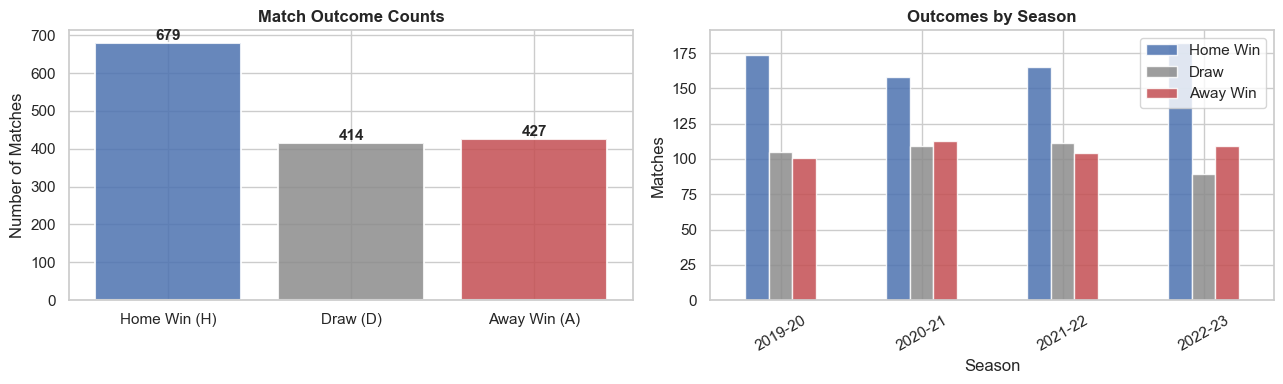

Home advantage: 44.7% of matches are Home Wins


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Absolute counts
counts = df['FTR'].value_counts()
labels = ['Home Win (H)', 'Draw (D)', 'Away Win (A)']
vals   = [counts.get('H',0), counts.get('D',0), counts.get('A',0)]
colors = ['#4C72B0', '#8c8c8c', '#C44E52']

bars = axes[0].bar(labels, vals, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
axes[0].set_title('Match Outcome Counts', fontweight='bold')
axes[0].set_ylabel('Number of Matches')
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 8, str(v),
                 ha='center', fontsize=11, fontweight='bold')

# By season
season_counts = df.groupby(['Season','FTR']).size().unstack(fill_value=0)
season_counts[['H','D','A']].plot(kind='bar', ax=axes[1],
    color=colors, alpha=0.85, edgecolor='white')
axes[1].set_title('Outcomes by Season', fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Matches')
axes[1].legend(['Home Win','Draw','Away Win'])
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()
print(f"Home advantage: {100*counts.get('H',0)/len(df):.1f}% of matches are Home Wins")

### 5.2 Goals Analysis

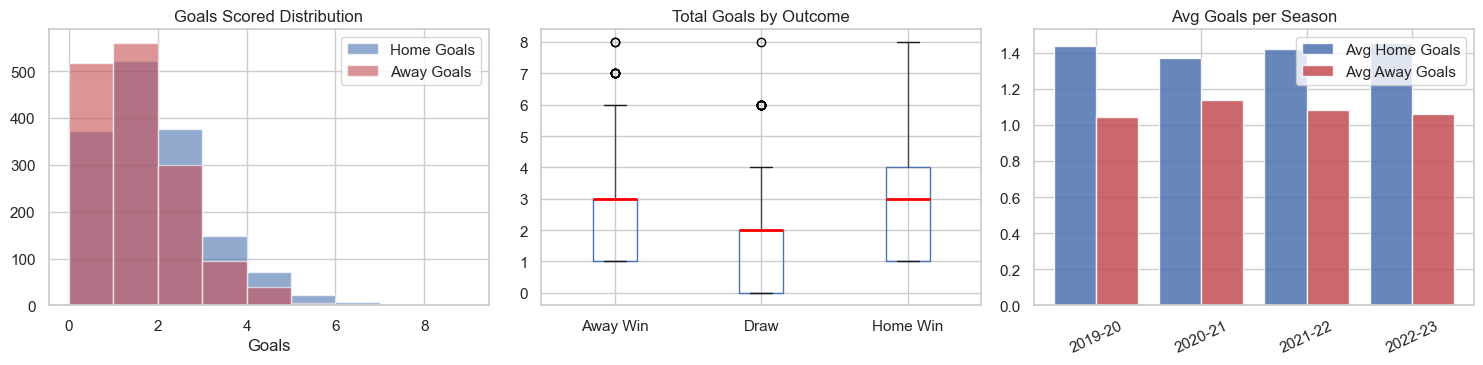

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Goal distributions
axes[0].hist(df['FTHG'], bins=range(0,10), alpha=0.6, label='Home Goals', color='#4C72B0')
axes[0].hist(df['FTAG'], bins=range(0,10), alpha=0.6, label='Away Goals', color='#C44E52')
axes[0].set_title('Goals Scored Distribution')
axes[0].set_xlabel('Goals')
axes[0].legend()

# Total goals by outcome
df_plot = df.copy()
df_plot['TotalGoals'] = df_plot['FTHG'] + df_plot['FTAG']
outcome_labels = {'H':'Home Win','D':'Draw','A':'Away Win'}
df_plot['OutcomeLabel'] = df_plot['FTR'].map(outcome_labels)
df_plot.boxplot(column='TotalGoals', by='OutcomeLabel', ax=axes[1],
                boxprops=dict(color='#4C72B0'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_xlabel('')
plt.sca(axes[1])
plt.title('Total Goals by Outcome')

# Home vs Away goals per season
season_goals = df.groupby('Season')[['FTHG','FTAG']].mean()
x = range(len(season_goals))
axes[2].bar([i-0.2 for i in x], season_goals['FTHG'], 0.4,
            label='Avg Home Goals', color='#4C72B0', alpha=0.85)
axes[2].bar([i+0.2 for i in x], season_goals['FTAG'], 0.4,
            label='Avg Away Goals', color='#C44E52', alpha=0.85)
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(season_goals.index, rotation=25)
axes[2].set_title('Avg Goals per Season')
axes[2].legend()

plt.suptitle('')
plt.tight_layout()
plt.show()

### 5.3 Correlation Heatmap

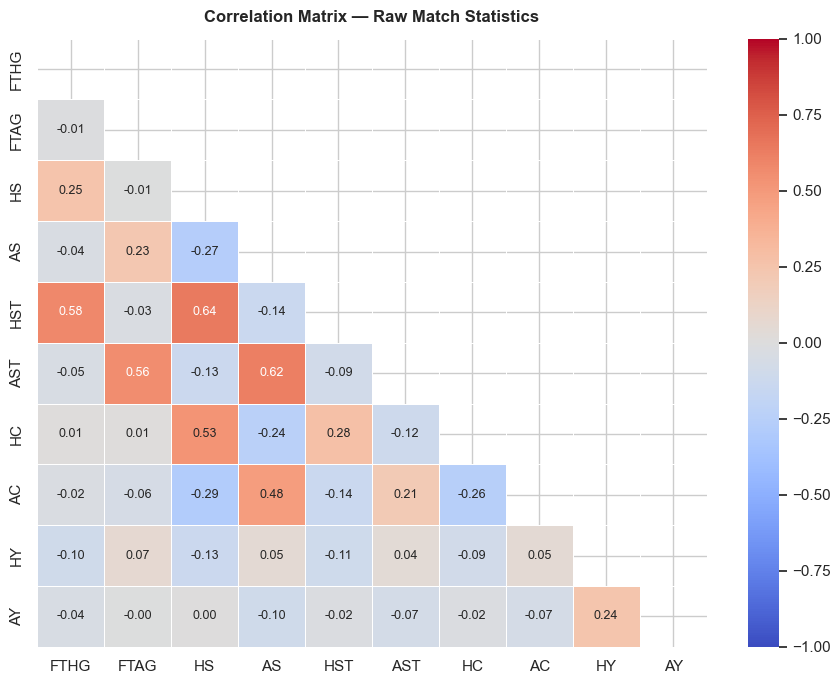

Note: HS & HST are highly correlated — difference features will partially address this.


In [8]:
numeric_cols = ['FTHG','FTAG','HS','AS','HST','AST','HC','AC','HY','AY']
numeric_cols = [c for c in numeric_cols if c in df.columns]

corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size':9})
plt.title('Correlation Matrix — Raw Match Statistics', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()
print("Note: HS & HST are highly correlated — difference features will partially address this.")

### 5.4 Team Rating Analysis (Source 2)

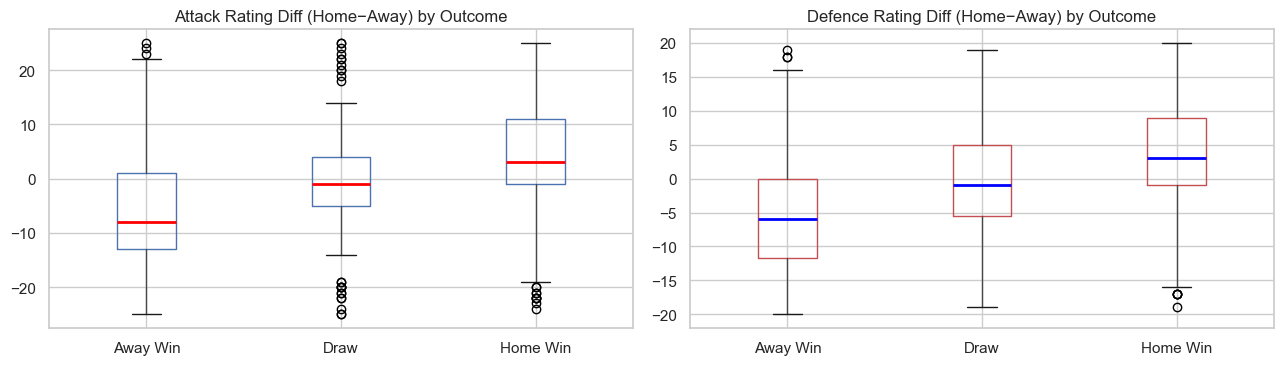

FIFA rating differentials show clear separation between Home Win and Away Win.


In [9]:
rating_cols = ['home_attack','home_defence','home_speed',
               'away_attack','away_defence','away_speed']
rating_cols = [c for c in rating_cols if c in df.columns]

if rating_cols:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    df_r = df.copy()
    df_r['AttackDiff_Rating']  = df_r['home_attack']  - df_r['away_attack']
    df_r['DefenceDiff_Rating'] = df_r['home_defence'] - df_r['away_defence']
    df_r['OutcomeLabel'] = df_r['FTR'].map({'H':'Home Win','D':'Draw','A':'Away Win'})

    df_r.boxplot(column='AttackDiff_Rating', by='OutcomeLabel', ax=axes[0],
                 boxprops=dict(color='#4C72B0'),
                 medianprops=dict(color='red', linewidth=2))
    axes[0].set_xlabel('')
    plt.sca(axes[0])
    plt.title('Attack Rating Diff (Home−Away) by Outcome')

    df_r.boxplot(column='DefenceDiff_Rating', by='OutcomeLabel', ax=axes[1],
                 boxprops=dict(color='#C44E52'),
                 medianprops=dict(color='blue', linewidth=2))
    axes[1].set_xlabel('')
    plt.sca(axes[1])
    plt.title('Defence Rating Diff (Home−Away) by Outcome')

    plt.suptitle('')
    plt.tight_layout()
    plt.show()
    print("FIFA rating differentials show clear separation between Home Win and Away Win.")
else:
    print("Team rating columns not found — check merge in Section 4.")